In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from joblib import Parallel, delayed
import time
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
    

from data_prep import create_artificial_dataset, load_spambase, load_sonar, load_breast_cancer_data
from missingness import MissingDataGenerator
from fista import FISTA
from unlabeled import UnlabeledLogReg

In [2]:
artificial_X, artificial_y = create_artificial_dataset()
spambase_X, spambase_y = load_spambase()
sonar_X, sonar_y = load_sonar()
breast_X, breast_y = load_breast_cancer_data()

Loading Spambase dataset...
Spambase loaded: X shape (4601, 57), y shape (4601,)
Loading Sonar dataset...
Sonar loaded: X shape (208, 60), y shape (208,)
Loading Breast Cancer dataset...
Breast Cancer loaded: X shape (569, 30), y shape (569,)
Positive labels (1s): 357 out of 569


# Experiments

In [4]:
# --- Experiment Helpers ---

# Create a clean dictionary to easily loop through your datasets
datasets = {
    "Artificial": (artificial_X, artificial_y),
    "Spambase": (spambase_X, spambase_y),
    "Sonar": (sonar_X, sonar_y),
    "BreastCancer": (breast_X, breast_y)
}

def evaluate_metrics(model, X_test, y_test):
    """Calculates all 4 required metrics for the report."""
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)[:, 1]
    
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Balanced_Acc": balanced_accuracy_score(y_test, preds),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, probas)
    }

def run_single_scheme_experiment(dataset_name, X, y, scheme_name):
    """Worker function to run one dataset + one scheme + all 4 models."""
    # 1. Split Data
    X_train, X_test, y_train_true, y_test_true = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 2. Apply chosen missingness scheme to TRAINING data only
    if scheme_name == 'MCAR':
        X_train, y_train_obs = MissingDataGenerator.apply_mcar(X_train, y_train_true, c=0.3, random_state=42)
    elif scheme_name == 'MAR1':
        X_train, y_train_obs = MissingDataGenerator.apply_mar1(X_train, y_train_true, random_state=42)
    elif scheme_name == 'MAR2':
        X_train, y_train_obs = MissingDataGenerator.apply_mar2(X_train, y_train_true, random_state=42)
    elif scheme_name == 'MNAR':
        X_train, y_train_obs = MissingDataGenerator.apply_mnar(X_train, y_train_true, random_state=42)
        
    results = []
    base_lambda = [0.01] # Keep it small for fast benchmarking
    
    # --- MODEL 1: ORACLE (Trained on 100% true labels) ---
    oracle = FISTA(lambdas=base_lambda).fit(X_train, y_train_true)
    res_oracle = evaluate_metrics(oracle, X_test, y_test_true)
    res_oracle.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Oracle"})
    results.append(res_oracle)
    
    # --- MODEL 2: NAIVE (FISTA trained ONLY on observed rows, ignoring -1s) ---
    naive_mask = y_train_obs != -1
    naive = FISTA(lambdas=base_lambda).fit(X_train[naive_mask], y_train_obs[naive_mask])
    res_naive = evaluate_metrics(naive, X_test, y_test_true)
    res_naive.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Naive"})
    results.append(res_naive)
    
    # --- MODEL 3: PSEUDO-LABELING ---
    pseudo = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method='pseudo_labeling')
    pseudo.fit(X_train, y_train_obs)
    res_pseudo = evaluate_metrics(pseudo, X_test, y_test_true)
    res_pseudo.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Pseudo-Labeling"})
    results.append(res_pseudo)
    
    # --- MODEL 4: EXPECTATION-MAXIMIZATION ---
    em = UnlabeledLogReg(model=FISTA(lambdas=base_lambda), method='em')
    em.fit(X_train, y_train_obs)
    res_em = evaluate_metrics(em, X_test, y_test_true)
    res_em.update({"Dataset": dataset_name, "Scheme": scheme_name, "Model": "Soft-EM"})
    results.append(res_em)
    
    return results

In [5]:
# --- Experiment 1 (Schemes Comparison) ---
print("Starting Experiment 1: Schemes Comparison across all datasets...")
start_time = time.time()

schemes = ['MCAR', 'MAR1', 'MAR2', 'MNAR']

# Build the grid of all combinations we need to run
tasks = []
for data_name, (X, y) in datasets.items():
    for scheme in schemes:
        tasks.append((data_name, X, y, scheme))

# Run in parallel! (n_jobs=-1 uses all your CPU cores)
# If this crashes your specific machine, change n_jobs to 2
all_results = Parallel(n_jobs=-1)(
    delayed(run_single_scheme_experiment)(d_name, X, y, sch) for d_name, X, y, sch in tasks
)

# Flatten the list of lists
flat_results = [item for sublist in all_results for item in sublist]

df_experiment1 = pd.DataFrame(flat_results)
df_experiment1 = df_experiment1[["Dataset", "Scheme", "Model", "Accuracy", "Balanced_Acc", "F1", "ROC_AUC"]]

print(f"Experiment 1 completed in {time.time() - start_time:.2f} seconds!")

# Display the grouped results (Perfect for your report!)
display(df_experiment1.groupby(['Dataset', 'Scheme', 'Model']).mean().round(4))

Starting Experiment 1: Schemes Comparison across all datasets...
Experiment 1 completed in 66.88 seconds!


Accuracy  Balanced_Acc      F1  ROC_AUC
Dataset    Scheme Model                                                   
Artificial MAR1   Naive              0.8575        0.8573  0.8535   0.9286
                  Oracle             0.8700        0.8700  0.8680   0.9428
                  Pseudo-Labeling    0.8575        0.8575  0.8550   0.9274
                  Soft-EM            0.8550        0.8549  0.8520   0.9282
           MAR2   Naive              0.8625        0.8627  0.8615   0.9320
...                                     ...           ...     ...      ...
Spambase   MCAR   Soft-EM            0.8219        0.8446  0.8252   0.8949
           MNAR   Naive              0.8252        0.8365  0.8152   0.8720
                  Oracle             0.8360        0.8262  0.7973   0.8746
                  Pseudo-Labeling    0.7796        0.8078  0.7922   0.8688
                  Soft-EM            0.7937        0.8167  0.7987   0.8675

[64 rows x 4 columns]

Starting Experiment 2: Parametric Analysis of 'c' on Breast Cancer Dataset...


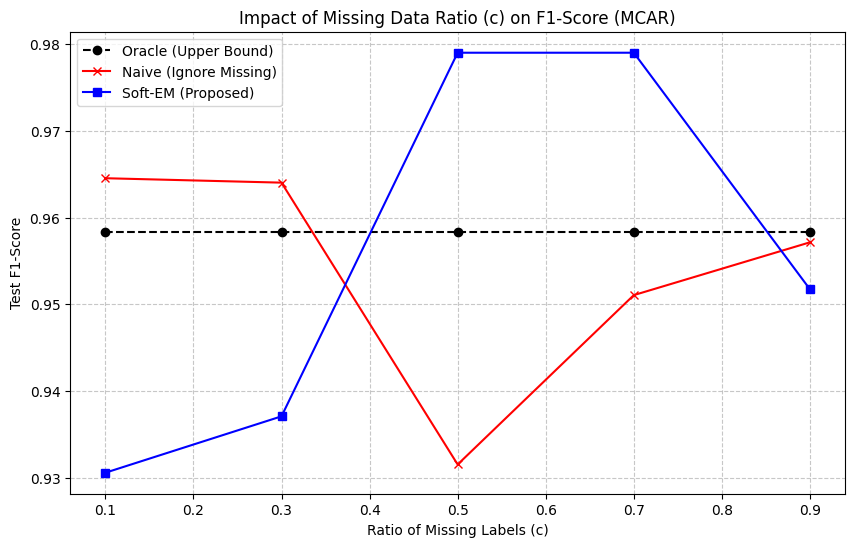

In [11]:
# --- CELL 7: Experiment 2 (MCAR 'c' Degradation) ---

print("Starting Experiment 2: Parametric Analysis of 'c' on Breast Cancer Dataset...")

c_values = [0.1, 0.3, 0.5, 0.7, 0.9]
X_bc, y_bc = datasets["BreastCancer"]
X_train, X_test, y_train_true, y_test_true = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

c_results = []

for c in c_values:
    # 1. Apply MCAR with specific 'c'
    # FIXED: We now pass X_train and unpack the returned tuple!
    _, y_train_obs = MissingDataGenerator.apply_mcar(X_train, y_train_true, c=c, random_state=42)
    
    # 2. Train Models
    # Oracle (constant, doesn't depend on c, but good for the baseline plot)
    oracle = FISTA(lambdas=[0.01]).fit(X_train, y_train_true)
    
    # Naive
    naive_mask = y_train_obs != -1
    naive = FISTA(lambdas=[0.01]).fit(X_train[naive_mask], y_train_obs[naive_mask])
    
    # EM
    em = UnlabeledLogReg(model=FISTA(lambdas=[0.01]), method='em').fit(X_train, y_train_obs)
    
    # 3. Log F1 Scores
    c_results.append({
        "c_value": c,
        "Oracle": f1_score(y_test_true, oracle.predict(X_test)),
        "Naive": f1_score(y_test_true, naive.predict(X_test)),
        "Soft-EM": f1_score(y_test_true, em.predict(X_test))
    })

df_c = pd.DataFrame(c_results).set_index("c_value")

# Plotting the degradation
plt.figure(figsize=(10, 6))
plt.plot(df_c.index, df_c['Oracle'], marker='o', linestyle='--', color='black', label='Oracle (Upper Bound)')
plt.plot(df_c.index, df_c['Naive'], marker='x', color='red', label='Naive (Ignore Missing)')
plt.plot(df_c.index, df_c['Soft-EM'], marker='s', color='blue', label='Soft-EM (Proposed)')

plt.title("Impact of Missing Data Ratio (c) on F1-Score (MCAR)")
plt.xlabel("Ratio of Missing Labels (c)")
plt.ylabel("Test F1-Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Starting Final FISTA Validation and Plotting...
Fitting FISTA model across 25 lambda values. This might take a few seconds...
Validation Complete! The optimal lambda penalty is: 0.0004

Generating Validation Plot (Metric vs Lambda)...


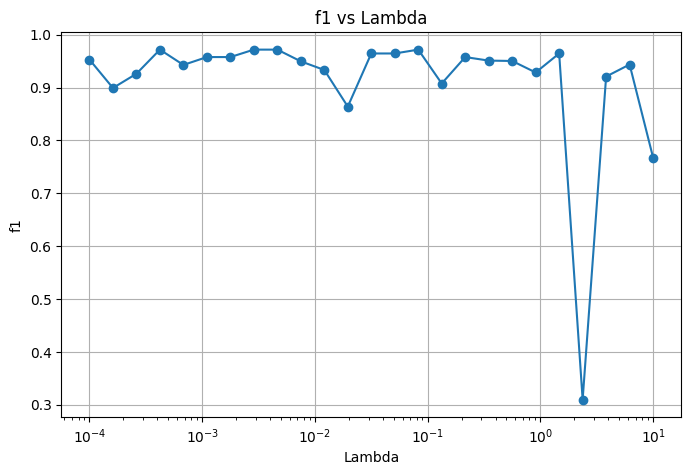


Generating Coefficient Path Plot (Lasso Feature Selection)...


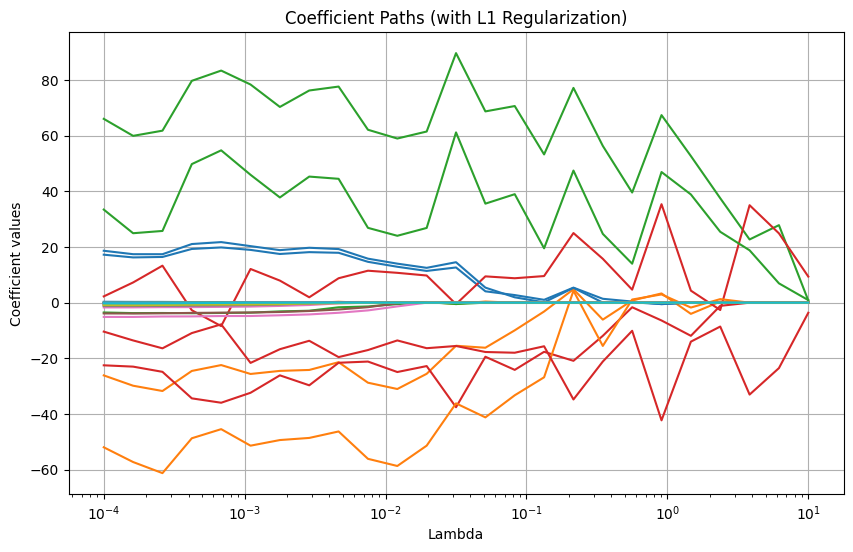

In [12]:
# --- Task 2 Validation & Coefficient Path Plots ---

print("Starting Final FISTA Validation and Plotting...")

# 1. We will use Breast Cancer as it is clean and has lots of features (good for Lasso)
X_bc, y_bc = datasets["BreastCancer"]

# Split into Train and Validation sets
X_train, X_val, y_train, y_val = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42)

# 2. Initialize FISTA with a full range of 25 lambdas (from 0.0001 to 10)
lambda_grid = np.logspace(-4, 1, 25)
fista_tuner = FISTA(lambdas=lambda_grid, max_iter=500)

# 3. Fit the model (This calculates the entire regularization path)
print("Fitting FISTA model across 25 lambda values. This might take a few seconds...")
fista_tuner.fit(X_train, y_train)

# 4. Validate the model to find the best lambda based on the F1-score
best_lambda = fista_tuner.validate(X_val, y_val, measure='f1')
print(f"Validation Complete! The optimal lambda penalty is: {best_lambda:.4f}")

# 5. Generate the required plots for your report
print("\nGenerating Validation Plot (Metric vs Lambda)...")
fista_tuner.plot(measure='f1')

print("\nGenerating Coefficient Path Plot (Lasso Feature Selection)...")
fista_tuner.plot_coefficients()

# Sklearn comparison

In [13]:
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import f1_score

print("--- Sklearn L1 Comparison ---")
start = time.time()
# liblinear is required for l1 penalty in sklearn
sk_model = LogisticRegression(penalty='l1', solver='liblinear', C=1/0.01) # C is inverse of lambda
sk_model.fit(X_train, y_train_true)
sk_time = time.time() - start

sk_preds = sk_model.predict(X_test)
print(f"Sklearn Time: {sk_time:.4f} seconds")
print(f"Sklearn F1: {f1_score(y_test_true, sk_preds):.4f}")

--- Sklearn L1 Comparison ---
Sklearn Time: 0.0514 seconds
Sklearn F1: 0.9859


c:\Users\Pc\Desktop\rzeczy_na_studia\DS\sem_8\AML\Projects\Project 1\AML_Proj1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Pc\Desktop\rzeczy_na_studia\DS\sem_8\AML\Projects\Project 1\AML_Proj1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


# Running on new data

In [10]:
# --- RUN ALGORITHM ON NEW DATA ---

def run_on_custom_data(csv_path, target_column):
    print(f"Loading new data from {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # 1. Prep data
    X_new = df.drop(columns=[target_column]).values
    y_new = df[target_column].values
    
    # 2. Impute and scale (Good practice)
    X_new = SimpleImputer(strategy='mean').fit_transform(X_new)
    X_new = StandardScaler().fit_transform(X_new)
    
    # 3. Train your UnlabeledLogReg directly
    model = UnlabeledLogReg(model=FISTA(lambdas=[0.01]), method='em')
    model.fit(X_new, y_new) 
    print("Model successfully trained on new data!")
    return model